# Get complementary info for the TFM report regarding the TDE candidates
Input: TDE_candidates_infos.csv from the candidates analysis, Entries_galaxies.csv the complete galaxies UV catalogue

Output: The candidates galactic positions map and the curve of the peak luminosity with respect to SMBH mass according to the Mummery theoritical fit

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
import numpy as np
roots_tfm = '/home/julien/Documents/Etudes/Astrofisica/Master/TFM/Data'

In [2]:
df=pd.read_csv(roots_tfm + '/TDE/Candidates/Post-filtering-best-candidates/TDE_candidates_infos.csv')

In [3]:
ra  = df['RA'].values   # deg
dec = df['DEC'].values  # deg

In [4]:
# Get the galactic coordinate
coords = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')
coords_gal = coords.galactic
l_rad  = -coords_gal.l.wrap_at(180 * u.deg).rad
b_rad = coords_gal.b.rad

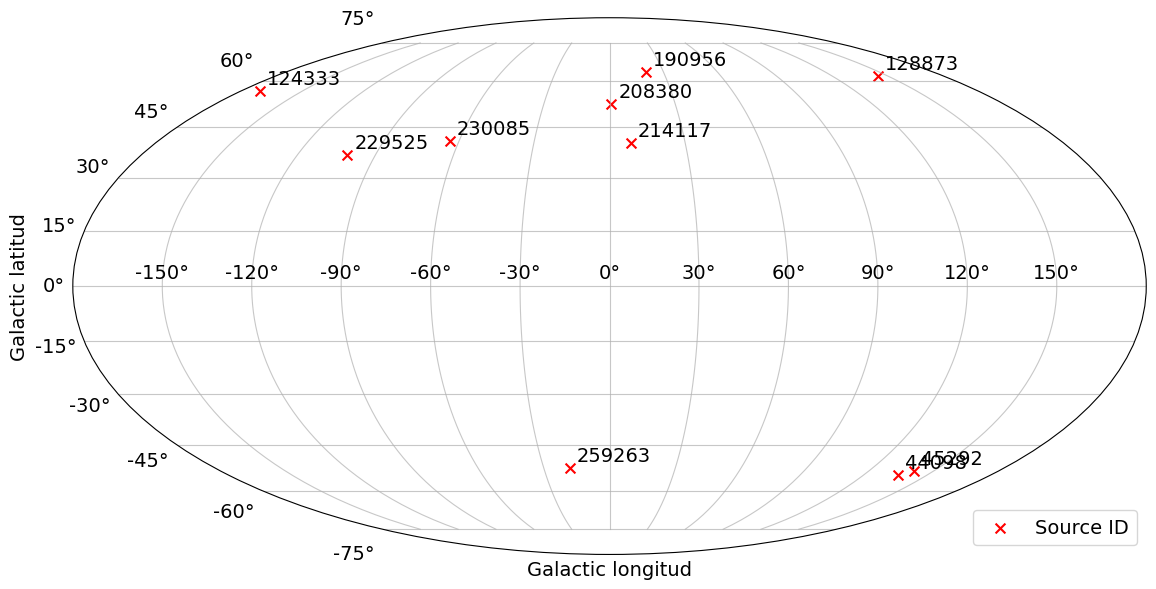

In [5]:
# Print the figure using the mollweide projection
fig = plt.figure(figsize=(12, 6))
ax  = fig.add_subplot(111, projection='mollweide')

sc = ax.scatter(l_rad,b_rad, c='red',s=50,marker='x',label='Source ID')
ax.set_xlabel('Galactic longitud', fontsize=14)
ax.set_ylabel('Galactic latitud', fontsize=14)
#ax.set_title('Best candidates position')

# Annotate each of the points with its source number
for i, srcnum in enumerate(df['SRCNUM_CUV']):
    ax.annotate(str(srcnum),(l_rad[i], b_rad[i]),textcoords='offset points', xytext=(5,5), fontsize=14)

# Add grid, ticks, show and save the figure
ax.grid(True, alpha=0.7)
plt.legend(loc='lower right',prop={'size': 14})
# Remettre les labels RA en degrés (0°–360°)
#tick_labels = ['150°','120°','90°','60°','30°','0°','330°','300°','270°','240°','210°']
#ax.set_xticklabels(tick_labels, fontsize=8)
ax.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.show()
fig.savefig(roots_tfm + '/TDE/Candidates/Post-filtering-best-candidates/Candidates_sky_map.png',\
                dpi=1200,bbox_inches="tight")

In [6]:
df_entries = pd.read_csv(roots_tfm +'/Entries_galaxies.csv',low_memory=False)

In [7]:
# Select the entries from the best candidates within the complete catalogue
df_entries = df_entries[df_entries['SRCNUM_CUV'].isin(df['SRCNUM_CUV'])]

# Compute the peak of the UVW2 flux for the candidates and the associated error
df_entries['UVW2_FLUX_idmax'] = df_entries['UVW2_FLUX'].copy()
df_entries_group = df_entries.groupby('SRCNUM_CUV').agg({'SRCNUM_CUV':'first', 'UVW2_FLUX' : 'max', 'UVW2_FLUX_idmax' : 'idxmax'})
df_entries_group['UVW2_FLUX_ERR'] = df_entries.loc[df_entries_group['UVW2_FLUX_idmax'].values,'UVW2_FLUX_ERR'].values

In [8]:
df_entries_group

,SRCNUM_CUV,UVW2_FLUX,UVW2_FLUX_idmax,UVW2_FLUX_ERR
SRCNUM_CUV,,,,
44098,44098,4.042539e-17,8013,1.210274e-17
45292,45292,5.817420e-17,1185278,8.892006e-18
124333,124333,8.448744e-17,769110,5.650544e-18
128873,128873,1.227854e-16,776839,2.791377e-18
190956,190956,4.215410e-17,938402,3.273528e-18
208380,208380,1.607578e-16,980207,8.603830e-18
214117,214117,1.210250e-16,993881,1.184664e-17
229525,229525,1.589978e-16,1262371,1.603873e-17
230085,230085,1.230264e-16,1495118,2.025129e-17


In [9]:
# Define manually the peak value and the band width according the instrument
df['F_peak']=[4E-17, 4.5E-17,8E-17,1E-16,4E-17,2E-16,1E-16,2E-16,1E-16,4E-16]
band=['OM UVW2','UVOT UVW2','UVOT UVW2','UVOT UVW2','UVOT UVW2','UVOT UVW2','UVOT UVW2','GALEX UVW2','UVOT UVW2','GALEX UVW2']
df_entries_group['band_width'] = [500, 657, 657, 657, 657, 657, 657, 657, 657, 657]
df_entries_group.reset_index

<bound method DataFrame.reset_index of             SRCNUM_CUV     UVW2_FLUX  UVW2_FLUX_idmax  UVW2_FLUX_ERR  \
SRCNUM_CUV                                                             
44098            44098  4.042539e-17             8013   1.210274e-17   
45292            45292  5.817420e-17          1185278   8.892006e-18   
124333          124333  8.448744e-17           769110   5.650544e-18   
128873          128873  1.227854e-16           776839   2.791377e-18   
190956          190956  4.215410e-17           938402   3.273528e-18   
208380          208380  1.607578e-16           980207   8.603830e-18   
214117          214117  1.210250e-16           993881   1.184664e-17   
229525          229525  1.589978e-16          1262371   1.603873e-17   
230085          230085  1.230264e-16          1495118   2.025129e-17   
259263          259263  4.196015e-16          1113090   1.913646e-17   

            band_width  
SRCNUM_CUV              
44098              500  
45292              65

In [10]:
# Luminosity function of the distance x, the flux y and the band width z
def f1(x,y,z):
    return 4*np.pi*((x*3.0857E24)**2)*y*z

In [11]:
# Log mass BH according to the x coefficient, y factor and log mass galaxy z
def f2(x,y,z):
    return x + y*(z-np.log10(3E10))

In [12]:
N=10000

In [13]:
# Definition of a normal flux law to compute the error in luminosity calculation
y = np.random.normal(loc=df_entries_group['UVW2_FLUX'].values[:,None],
                     scale=df_entries_group['UVW2_FLUX_ERR'].values[:,None],
                     size=(len(df_entries_group),N))
x = df['D'].values[:,None]
z = df_entries_group['band_width'].values[:,None]
results = f1(x,y,z)
df['L_peak_err'] = results.std(axis=1)

In [14]:
# Definition of a normal distributions to compute the error in log mass black holes distribution
x = np.random.normal(7.44, 0.04, size=(1,N))
y = np.random.normal(1.42, 0.07, size=(1,N))
z = df['logM'].values[:,None]
results2 = f2(x,y,z)
df['logMBHerr'] = results2.std(axis=1).mean()

In [15]:
# Computation of the peak of luminosity
df['L_peak'] = 4*np.pi*((df['D']*3.0857E24)**2) * df_entries_group['UVW2_FLUX'].values * df_entries_group['band_width'].values #Band UVOT UVW2 from Poole 2008 Photometric calibration 

In [16]:
#df['L_peak_err'] = 4*np.pi*((df['D']*3.0857E24)**2) * df_entries_group['UVW2_FLUX_ERR'].values * df_entries_group['band_width'].values

In [17]:
# Computation of the black hole mass using the Mummery fit
df['logMBH']= 7.44 + 1.42 * (df['logM'] - np.log10(3E10))

In [18]:
# Another way to compute the black hole mass error using the error provided by Mummery
df['logMBHerr'] = 0.04 + 0.17 * abs(df['logM'] - np.log10(3E10))

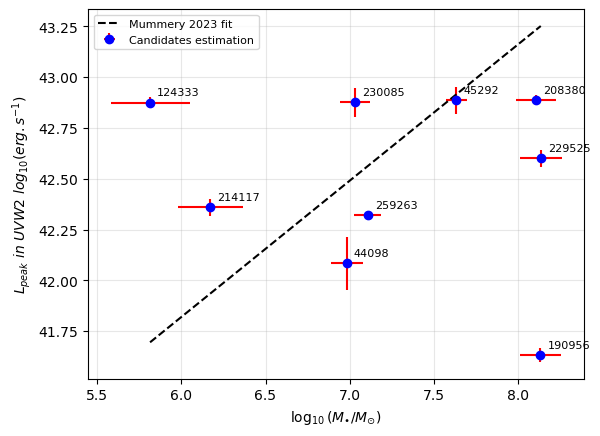

In [19]:
# Plot of the resulting curve
fig, ax =plt.subplots()
#sc = ax.scatter(df['logMBH'],np.log10(df['L_peak']), c='red',s=50,marker='x',label='Candidates TDE')

# Plot using errorbar
ax.errorbar(df['logMBH'],np.log10(df['L_peak']), xerr=df['logMBHerr'],\
                        yerr=df['L_peak_err']/(df['L_peak']*np.log(10)), \
                        fmt='o', color='blue', \
                        ecolor='red',label='Candidates estimation')

# Remove of index far from the fit 
ind = ~(df['SRCNUM_CUV'] == 124333) & ~(df['SRCNUM_CUV'] == 190956)
x = df.loc[ind,'logMBH'].values.astype(float)
y = np.log10(df.loc[ind,'L_peak'].values.astype(float))

# Remove of infite points
mask = np.isfinite(x) & np.isfinite(y)

# Fit of our distribution
p = np.poly1d(np.polyfit(x[mask], y[mask], deg=1))
xp = np.linspace(df['logMBH'].min(), df['logMBH'].max(), 100)
#ax.plot(xp, p(xp), color='b', linestyle='dashed', label= "Candidates fit") 

# Plot of the Mummery fit
ax.plot(xp, 0.67*xp+37.8, color='k', linestyle='dashed', label= "Mummery 2023 fit")

# Add label and annotation
ax.set_xlabel(r'$\log_{10}(M_{\bullet}/M_{\odot})$')
ax.set_ylabel(r'$L_{peak}\ in\ UVW2\ log_{10}(erg.s^{-1})\ $')
for i, srcnum in enumerate(df['SRCNUM_CUV']):
    ax.annotate(str(srcnum),(df.loc[i,'logMBH'], np.log10(df.loc[i,'L_peak'])),textcoords='offset points', xytext=(5,5), fontsize=8)

# Add grid, label, show and save the figure
ax.grid(True, alpha=0.3)
plt.legend(loc='best',prop={'size': 8})
plt.show()
fig.savefig(roots_tfm + '/TDE/Candidates/Post-filtering-best-candidates/TDE_model_fit.png',\
                dpi=1200,bbox_inches="tight")